In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical

2026-02-26 20:29:18.788600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772137758.941769      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772137758.989281      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772137759.368924      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772137759.368964      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772137759.368967      55 computation_placer.cc:177] computation placer alr

# 1- Charger et normaliser les données

In [3]:
# Chargement MNIST
(X_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalisation [-1, 1] (adapté au tanh du générateur)
X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = X_train[..., np.newaxis]  # (60000, 28, 28, 1)

# One-Hot Encoding des labels
NUM_CLASSES = 10
y_train_ohe = to_categorical(y_train, NUM_CLASSES)

print("X_train shape:", X_train.shape)
print("y_train_ohe shape:", y_train_ohe.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28, 1)
y_train_ohe shape: (60000, 10)


# 2- Construire le générateur

In [ ]:
LATENT_DIM = 100

def build_generator():

    noise_input = layers.Input(shape=(LATENT_DIM,), name="noise")
    label_input = layers.Input(shape=(NUM_CLASSES,), name="label")

    x = layers.Concatenate()([noise_input, label_input])

    x = layers.Dense(7 * 7 * 128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 128))(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)  # (14, 14, 64)

    x = layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='tanh')(x)
    # output: (28, 28, 1)

    model = Model([noise_input, label_input], x, name="Generator")
    return model

generator = build_generator()
generator.summary()

I0000 00:00:1772137829.910838      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772137829.916782      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 110)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6272)      │    689,920 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 6272)      │     25,088 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 6272)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 7, 128) │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    131,072 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28, 1) │      1,025 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 847,361 (3.23 MB)

 Trainable params: 834,689 (3.18 MB)

 Non-trainable params: 12,672 (49.50 KB)

# 3- Construire le discriminateur

In [ ]:
def build_discriminator():

    image_input = layers.Input(shape=(28, 28, 1), name="image")
    label_input = layers.Input(shape=(NUM_CLASSES,), name="label")

    label_emb = layers.Dense(28 * 28 * 1)(label_input)
    label_emb = layers.Reshape((28, 28, 1))(label_emb)

    # image + label map  (28, 28, 2)
    x = layers.Concatenate()([image_input, label_emb])

    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)   # (14, 14, 64)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)   # (7, 7, 128)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    model = Model([image_input, label_input], x, name="Discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 784)       │      8,624 │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ image[0][0],      │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │      2,112 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 14, 14,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ leaky_re_lu_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 128) │    131,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 7, 7, 128) │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 128) │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 6272)      │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      6,273 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 148,209 (578.94 KB)

 Trainable params: 148,209 (578.94 KB)

 Non-trainable params: 0 (0.00 B)

# 4- Définir la fonction de perte et les optimizers

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer     = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# 5- Entraîner le modèle

In [ ]:
BATCH_SIZE = 128
EPOCHS     = 30

@tf.function
def train_step(real_images, real_labels):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])
    
    # random label for fake image
    fake_labels = to_categorical(
        np.random.randint(0, NUM_CLASSES, BATCH_SIZE), NUM_CLASSES
    )
    fake_labels = tf.cast(fake_labels, tf.float32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator([noise, fake_labels], training=True)

        real_output = discriminator([real_images, real_labels], training=True)
        fake_output = discriminator([fake_images, fake_labels], training=True)

        gen_loss  = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients  = gen_tape.gradient(gen_loss,  generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients,  generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss



dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_ohe)) \
            .shuffle(60000).batch(BATCH_SIZE, drop_remainder=True)

# loss history
gen_losses, disc_losses = [], []

for epoch in range(EPOCHS):
    g_loss_epoch, d_loss_epoch = 0, 0
    num_batches = 0

    for real_images, real_labels in dataset:
        g_loss, d_loss = train_step(real_images, real_labels)
        g_loss_epoch += g_loss.numpy()
        d_loss_epoch += d_loss.numpy()
        num_batches  += 1

    g_loss_epoch /= num_batches
    d_loss_epoch /= num_batches
    gen_losses.append(g_loss_epoch)
    disc_losses.append(d_loss_epoch)

    print(f"Epoch {epoch+1}/{EPOCHS} | G Loss: {g_loss_epoch:.4f} | D Loss: {d_loss_epoch:.4f}")

E0000 00:00:1772137853.882198      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772137855.035267     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/30 | G Loss: 0.8619 | D Loss: 1.1382
Epoch 2/30 | G Loss: 0.8018 | D Loss: 1.3019
Epoch 3/30 | G Loss: 0.8501 | D Loss: 1.2366
Epoch 4/30 | G Loss: 0.9318 | D Loss: 1.1676
Epoch 5/30 | G Loss: 0.9952 | D Loss: 1.1369
Epoch 6/30 | G Loss: 0.9904 | D Loss: 1.1540
Epoch 7/30 | G Loss: 0.9724 | D Loss: 1.1810
Epoch 8/30 | G Loss: 0.9677 | D Loss: 1.1872
Epoch 9/30 | G Loss: 0.9457 | D Loss: 1.2102
Epoch 10/30 | G Loss: 0.9245 | D Loss: 1.2248
Epoch 11/30 | G Loss: 0.9073 | D Loss: 1.2386
Epoch 12/30 | G Loss: 0.9006 | D Loss: 1.2427
Epoch 13/30 | G Loss: 0.9030 | D Loss: 1.2366
Epoch 14/30 | G Loss: 0.8957 | D Loss: 1.2404
Epoch 15/30 | G Loss: 0.8977 | D Loss: 1.2397
Epoch 16/30 | G Loss: 0.8964 | D Loss: 1.2398
Epoch 17/30 | G Loss: 0.8980 | D Loss: 1.2408
Epoch 18/30 | G Loss: 0.9031 | D Loss: 1.2384
Epoch 19/30 | G Loss: 0.8945 | D Loss: 1.2454
Epoch 20/30 | G Loss: 0.8983 | D Loss: 1.2427
Epoch 21/30 | G Loss: 0.8923 | D Loss: 1.2477
Epoch 22/30 | G Loss: 0.8940 | D Loss: 1.24

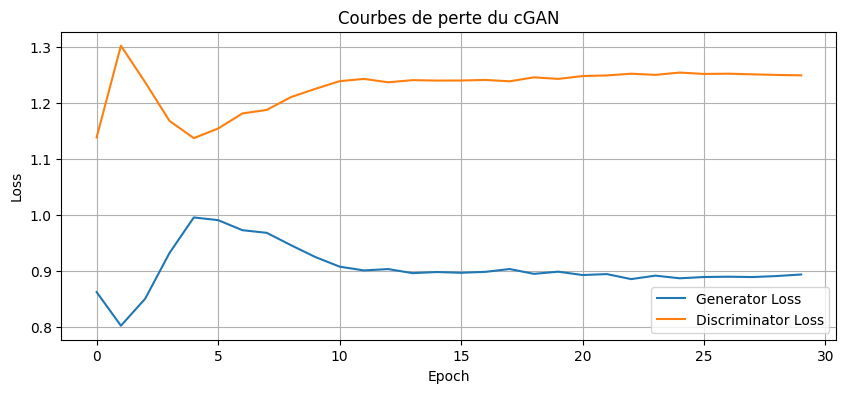

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(gen_losses,  label='Generator Loss')
plt.plot(disc_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes de perte du cGAN')
plt.legend()
plt.grid(True)
plt.show()

# 6- Générer des images conditionnées

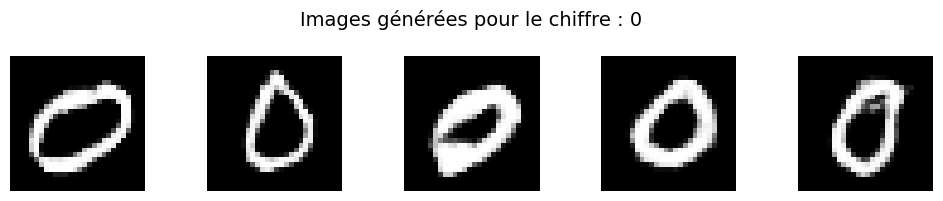

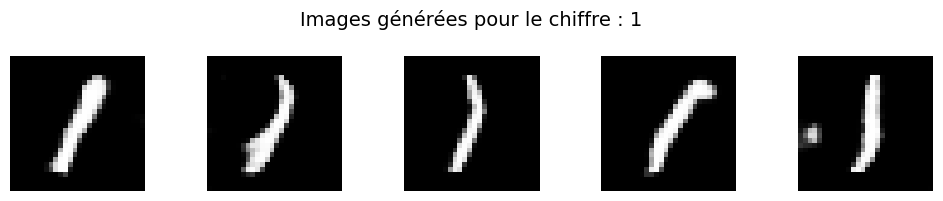

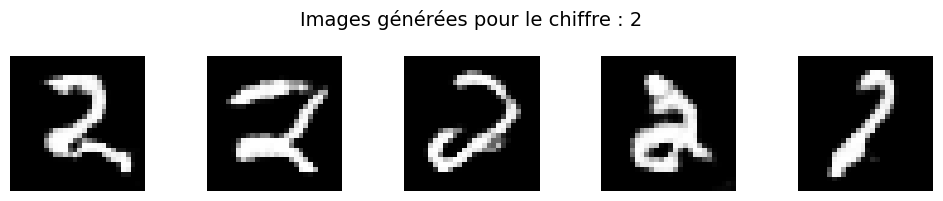

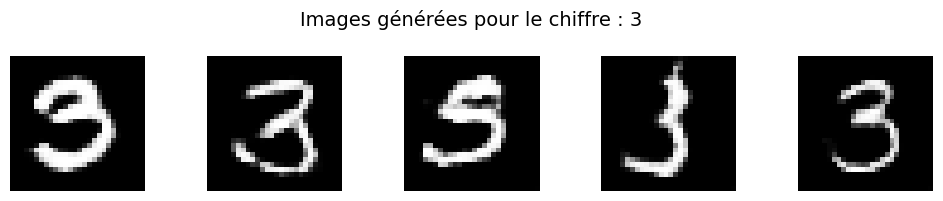

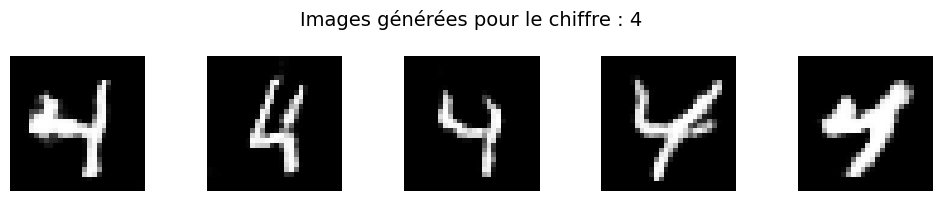

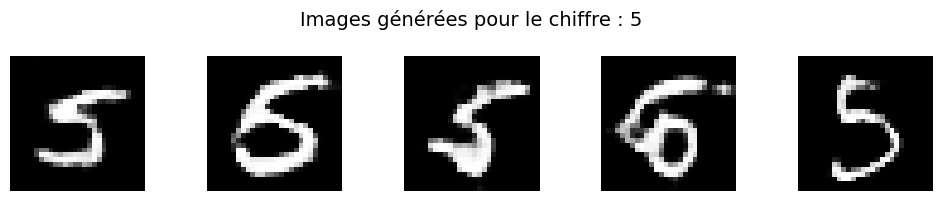

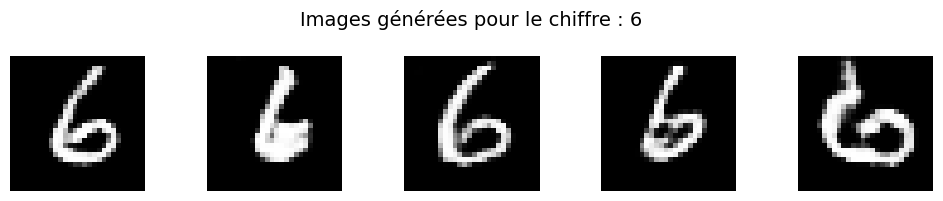

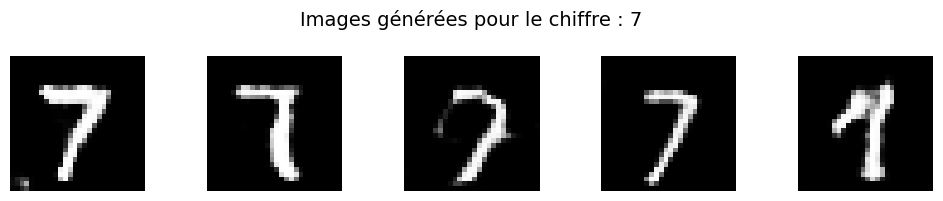

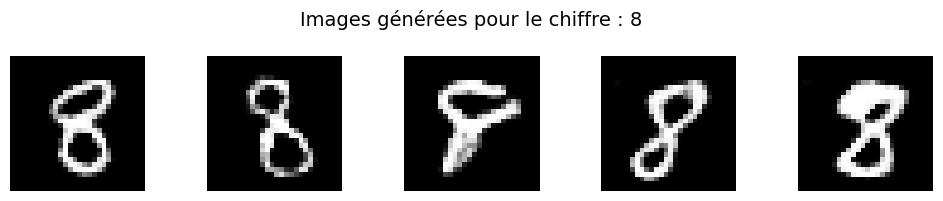

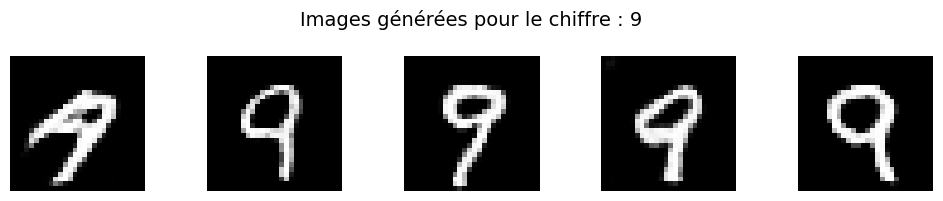

In [ ]:
def generate_images(digit, num_images=5):
    noise = tf.random.normal([num_images, LATENT_DIM])
    labels = to_categorical([digit] * num_images, NUM_CLASSES)
    labels = tf.cast(labels, tf.float32)
    
    generated = generator([noise, labels], training=False).numpy()
    generated = (generated * 127.5 + 127.5).astype(np.uint8)

    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2, 2))
    for i, ax in enumerate(axes):
        ax.imshow(generated[i, :, :, 0], cmap='gray')
        ax.axis('off')
    plt.suptitle(f"Images générées pour le chiffre : {digit}", fontsize=14)
    plt.tight_layout()
    plt.show()

for digit in range(10):
    generate_images(digit)

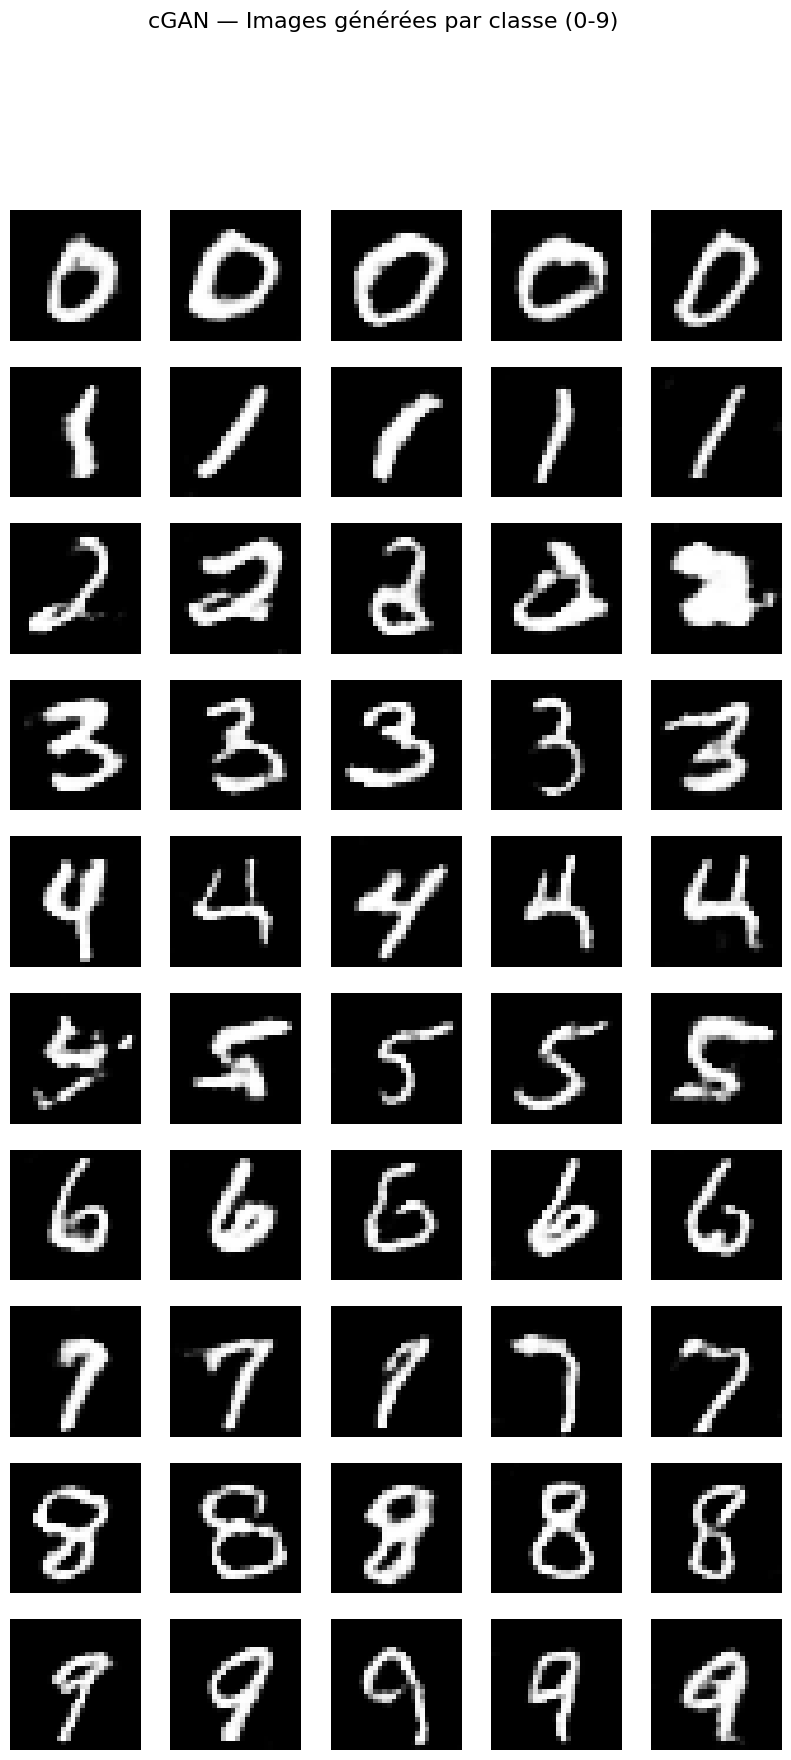

In [11]:
fig, axes = plt.subplots(10, 5, figsize=(10, 20))

for digit in range(10):
    noise  = tf.random.normal([5, LATENT_DIM])
    labels = to_categorical([digit] * 5, NUM_CLASSES)
    labels = tf.cast(labels, tf.float32)
    imgs   = generator([noise, labels], training=False).numpy()
    imgs   = (imgs * 127.5 + 127.5).astype(np.uint8)
    
    for col in range(5):
        axes[digit][col].imshow(imgs[col, :, :, 0], cmap='gray')
        axes[digit][col].axis('off')
        if col == 0:
            axes[digit][col].set_ylabel(str(digit), fontsize=14, rotation=0, labelpad=20)

plt.suptitle("cGAN — Images générées par classe (0-9)", fontsize=16)
#plt.tight_layout()
plt.show()


Q1 — Difference GAN vs cGAN :
  - GAN genere des images aleatoires sans controle.
  - cGAN conditionne la generation par un label y qui controle le contenu generé.

Q2 — Pourquoi conditionner ameliore la qualité ?
  - Le generateur et le discriminateur reçoivent le label y,
  ce qui guide l'apprentissage vers des distributions de classes précises
  et réduit l'espace de recherche.

Q3 — Detecter le mode collapse :
  - Toutes les images generées se ressemblent (peu de diversité).
  - La perte du generateur chute tres vite et reste stable.
  - La perte du discriminateur devient nulle.
  -> Solution : ajouter du dropout, changer le LR, utiliser minibatch discrimination.

Q4 — Impact du learning rate :
  - LR trop élevé -> instabilité, oscillations.
  - LR trop faible -> convergence tres lente.
  - LR recommandé pour les GANs : 0.0002 avec Adam (beta_1=0.5).
